In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline 
import warnings 
warnings.filterwarnings("ignore")

# Load Data

In [3]:
train = pd.read_csv('/Users/vydhyamvishnusai/LOAN APPROVAL CLASSIFICATION/loan_sanction_train.csv')
test = pd.read_csv('/Users/vydhyamvishnusai/LOAN APPROVAL CLASSIFICATION/loan_sanction_test.csv')

In [4]:
test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [5]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
train_original = train.copy()
test_original = test.copy()

In [8]:
train.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [9]:
test.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='str')

In [10]:
train.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [11]:
train.shape, test.shape

((614, 13), (367, 12))

# EXPLORATORY DATA ANALYSIS

In [12]:
train['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [13]:
train['Loan_Status'].value_counts(normalize = True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

<Axes: xlabel='Loan_Status'>

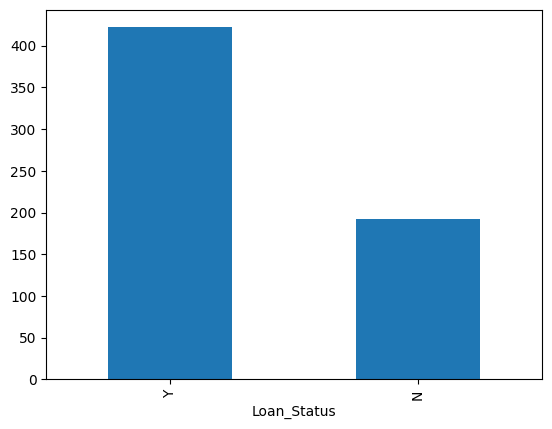

In [14]:
train['Loan_Status'].value_counts().plot(kind = 'bar')

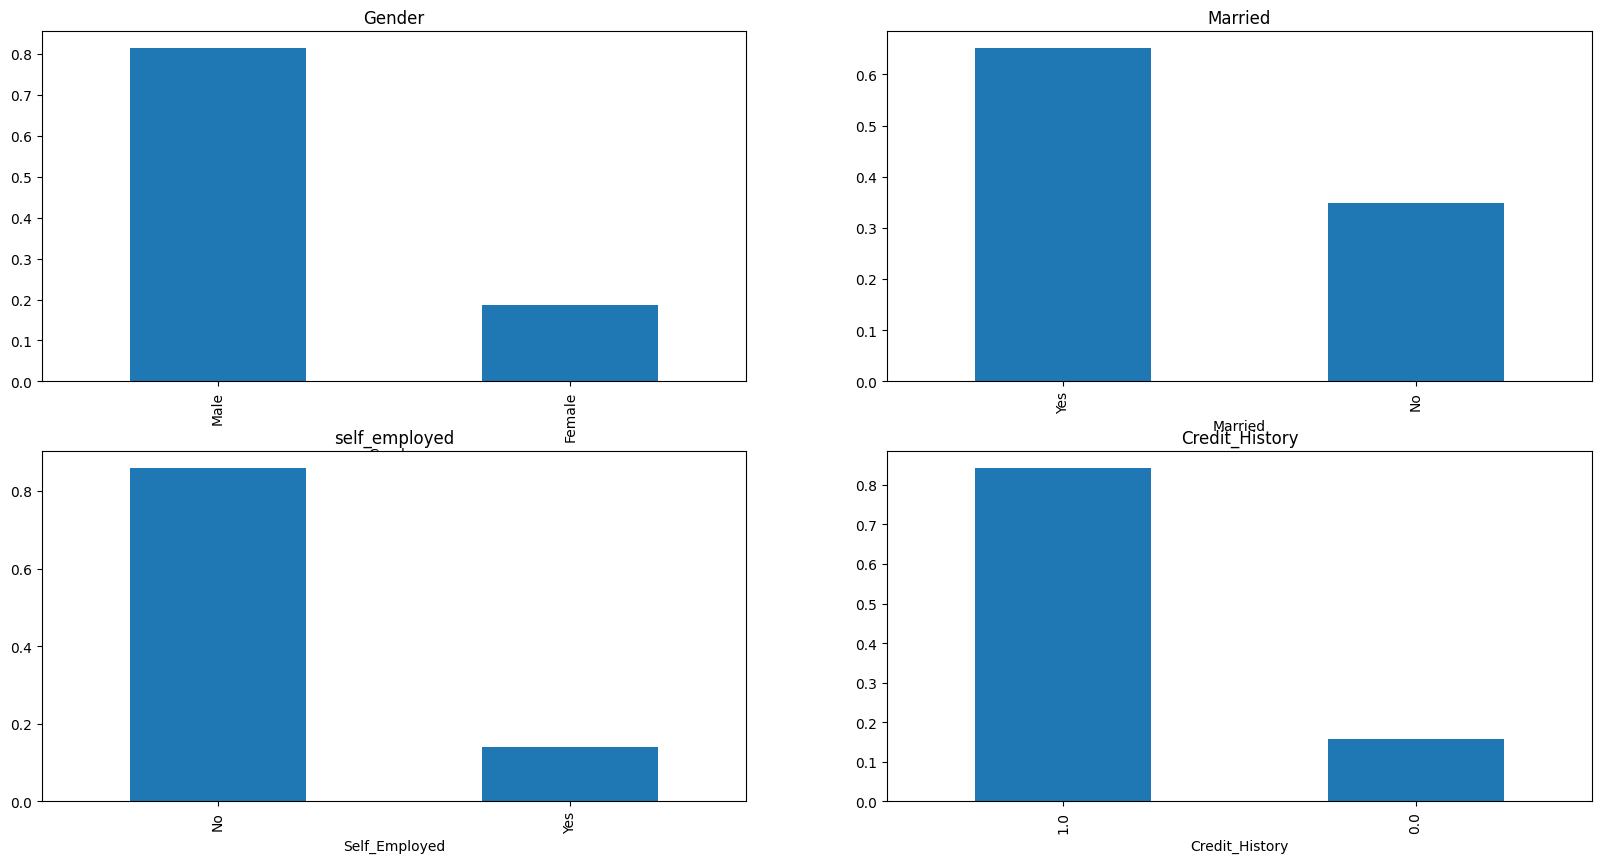

In [15]:
plt.figure(1)
plt.subplot(221) # plt.subplot (nrows, ncols, plot_number)
train['Gender'].value_counts(normalize = True).plot.bar( figsize = (20,10), title = "Gender")
plt.subplot(222)
train['Married'].value_counts(normalize = True).plot.bar(title = 'Married')
plt.subplot(223)
train['Self_Employed'].value_counts(normalize = True).plot.bar(title = 'self_employed')
plt.subplot(224)
train['Credit_History'].value_counts(normalize = True).plot.bar(title = 'Credit_History')
plt.show()

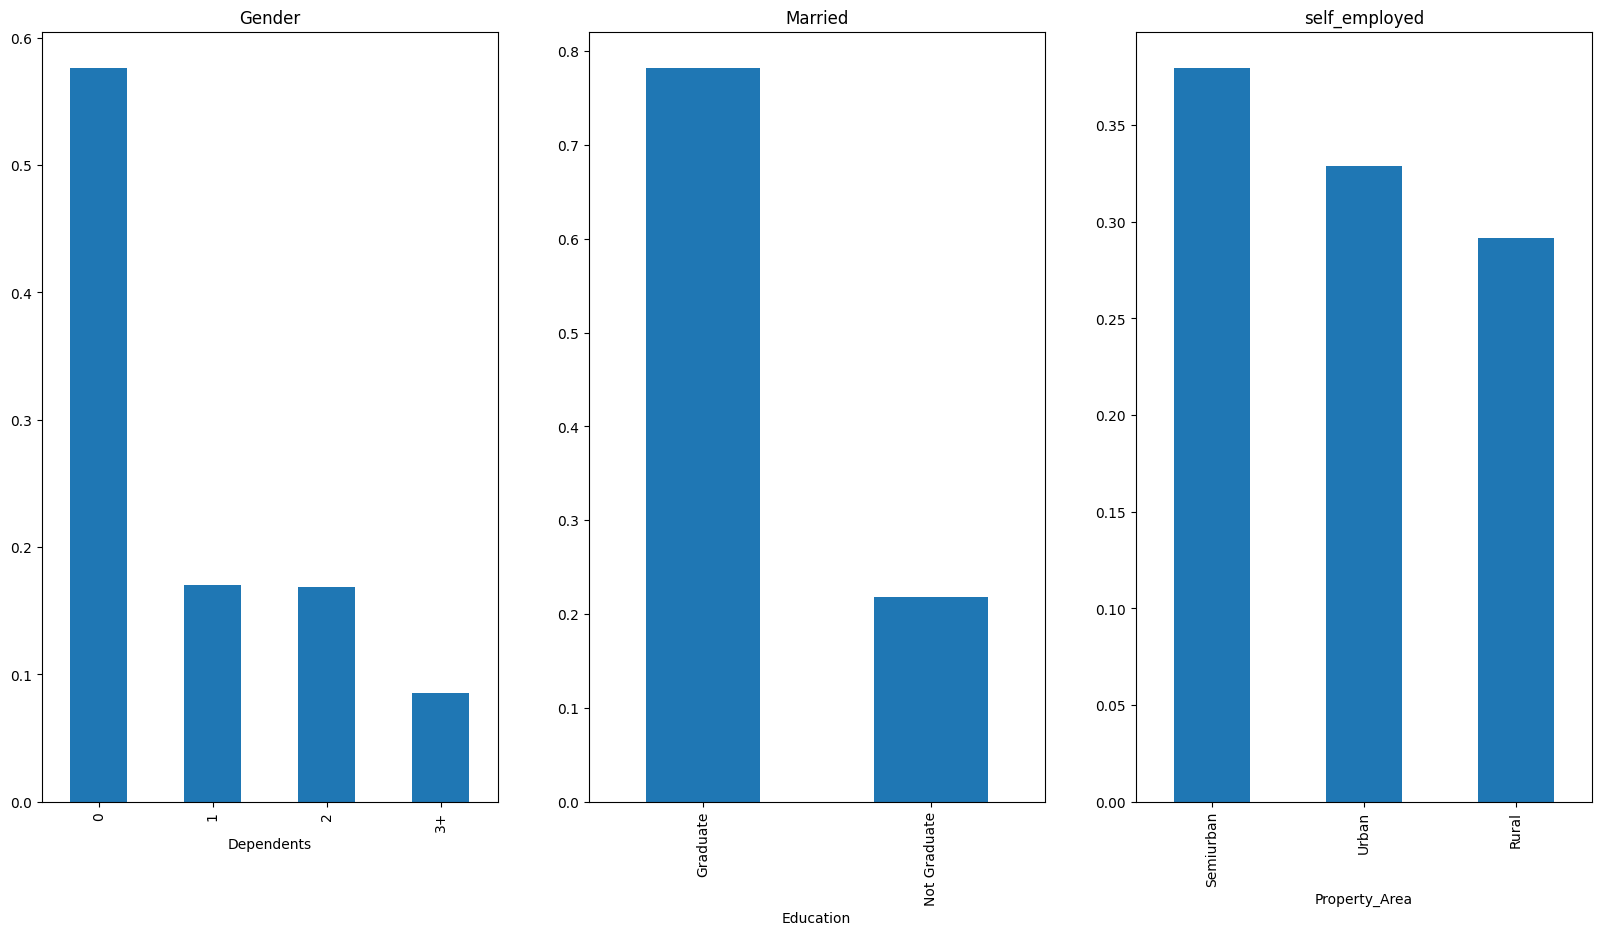

In [16]:
plt.figure(1)
plt.subplot(131) # plt.subplot (nrows, ncols, plot_number)
train['Dependents'].value_counts(normalize = True).plot.bar( figsize = (20,10), title = "Gender")
plt.subplot(132)
train['Education'].value_counts(normalize = True).plot.bar(title = 'Married')
plt.subplot(133)
train['Property_Area'].value_counts(normalize = True).plot.bar(title = 'self_employed')
plt.show()

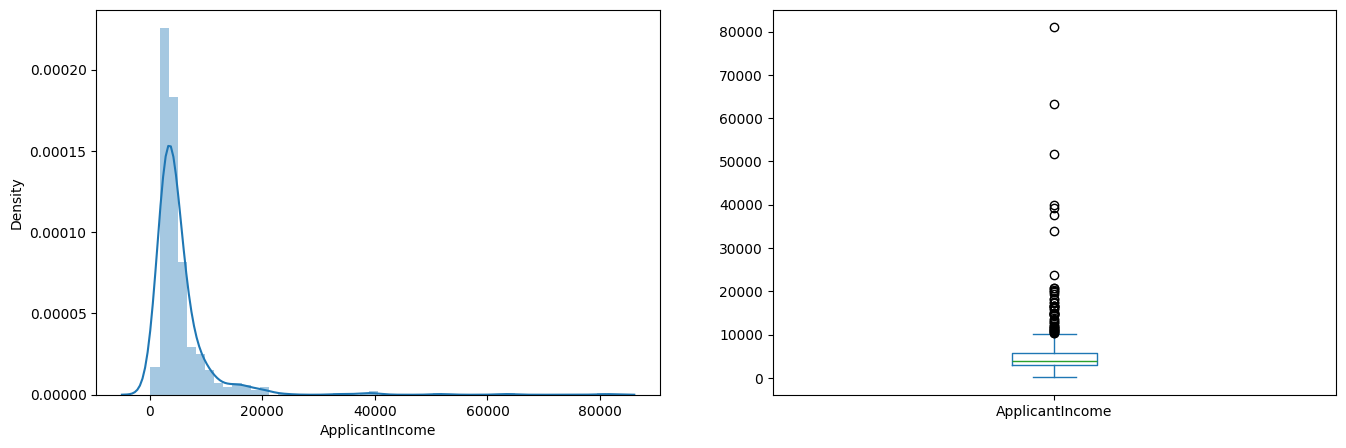

In [17]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train['ApplicantIncome'])
plt.subplot(122)
train['ApplicantIncome'].plot.box(figsize = (16,5))
plt.show()

Text(0.5, 0.98, '')

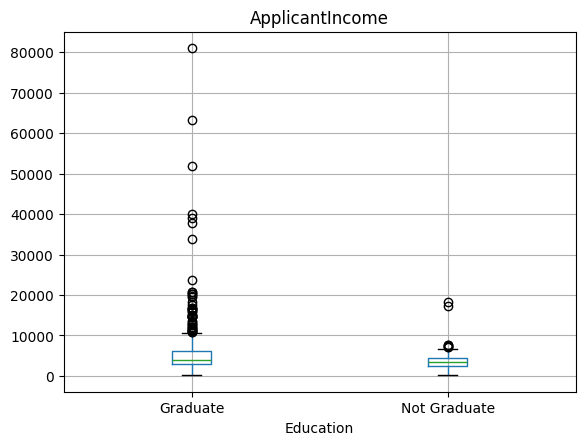

In [18]:
train.boxplot(column = "ApplicantIncome", by = "Education")
plt.suptitle("")

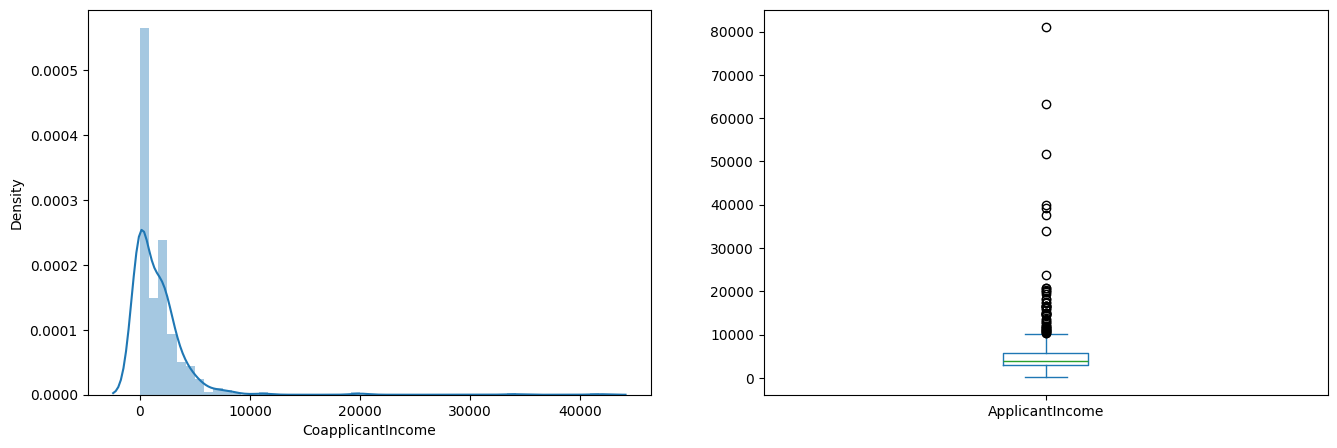

In [19]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train['CoapplicantIncome'])
plt.subplot(122)
train['ApplicantIncome'].plot.box(figsize = (16,5))
plt.show()

<Axes: xlabel='Gender'>

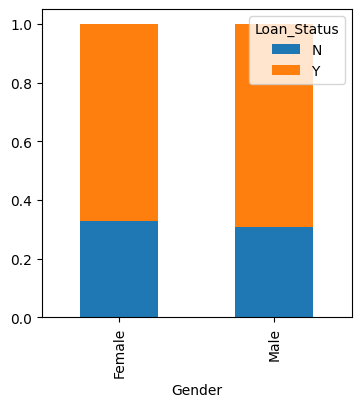

In [20]:
Gender = pd.crosstab(train['Gender'], train['Loan_Status'])
Gender.div(Gender.sum(1).astype(float), axis =0).plot(kind="bar",stacked=True,figsize=(4,4))

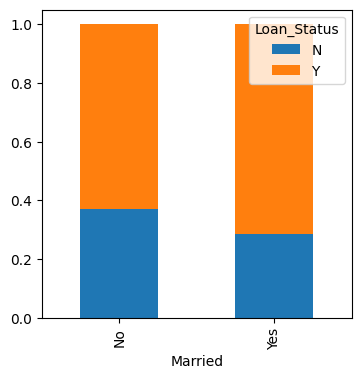

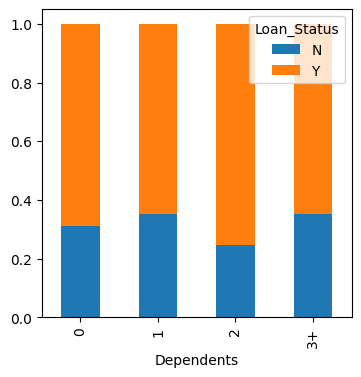

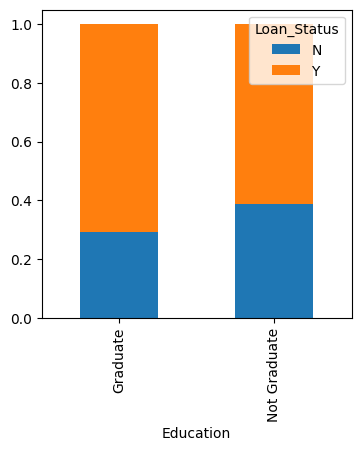

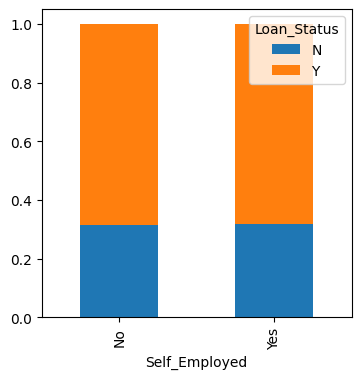

In [21]:
Married = pd.crosstab(train['Married'],train['Loan_Status'])
Dependents = pd.crosstab(train['Dependents'],train['Loan_Status'])
Education = pd.crosstab(train['Education'],train['Loan_Status'])
Self_Employed = pd.crosstab(train['Self_Employed'],train['Loan_Status'])
Married.div(Married.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()
Dependents.div(Dependents.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()
Education.div(Education.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()
Self_Employed.div(Self_Employed.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()

- Proportion of married applicant is higher for the approved loans.
- Distribution of applicant with 1 or 3+ dependets is similar accross both the categories of Loan_Status
- There is nothing significant we can infer from Self_Employed vs Loan_Status plot

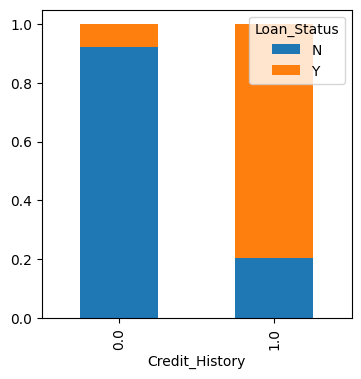

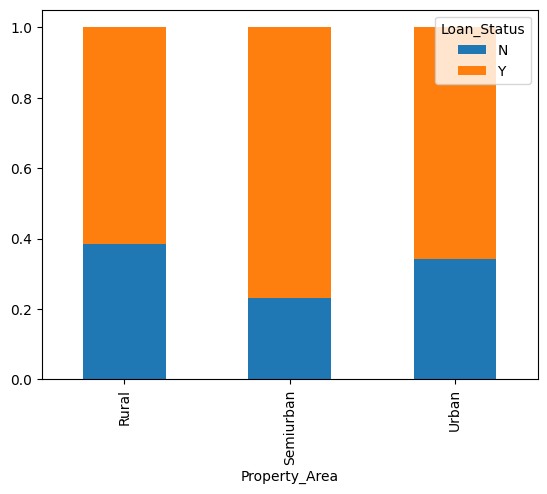

In [22]:
Credit_History = pd.crosstab(train['Credit_History'], train['Loan_Status'])
Property_Area = pd.crosstab(train['Property_Area'], train['Loan_Status'])
Credit_History.div(Credit_History.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()
Property_Area.div(Property_Area.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)
plt.show()

<Axes: xlabel='Loan_Status'>

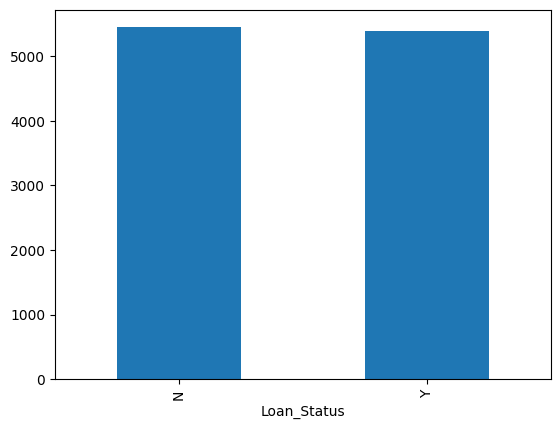

In [23]:
train.groupby('Loan_Status')['ApplicantIncome'].mean().plot.bar()

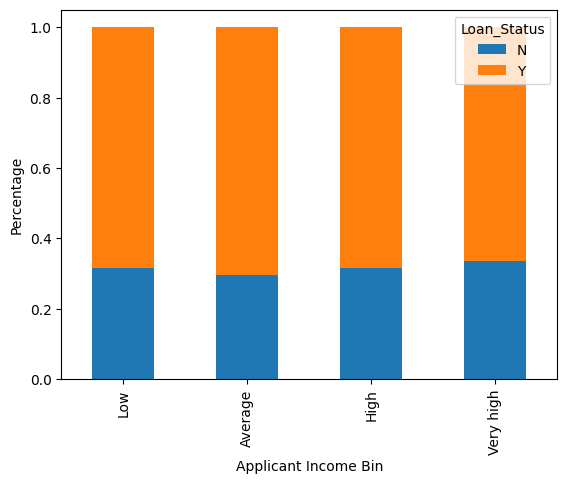

In [24]:
bins = [0, 2500, 4000, 6000, 81000]
group = ['Low', 'Average', 'High', 'Very high']
train['Income_bin'] = pd.cut(train['ApplicantIncome'], bins, labels=group)
Income_crosstab = pd.crosstab(train['Income_bin'], train['Loan_Status'])
Income_crosstab.div(Income_crosstab.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)
plt.xlabel('Applicant Income Bin') 
plt.ylabel('Percentage')
plt.show()

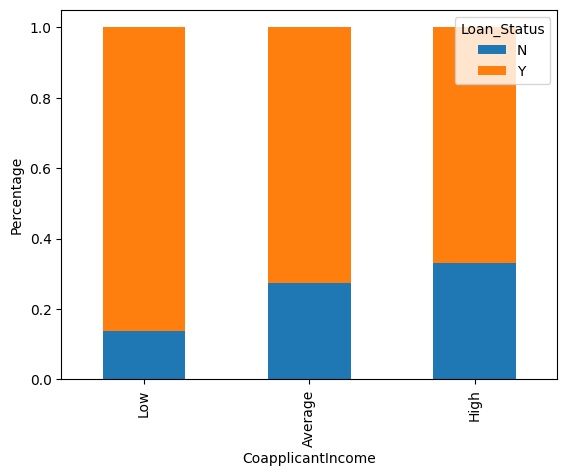

In [25]:
bins = [0,1000,3000,42000]
group = ['Low', 'Average', 'High']
train['Coapplicant_Income_bin'] = pd.cut(train['CoapplicantIncome'],bins,labels=group)
Coapplicant_Income_bin=pd.crosstab(train['Coapplicant_Income_bin'],train['Loan_Status'])
Coapplicant_Income_bin.div(Coapplicant_Income_bin.sum(1).astype(float), axis=0).plot(kind='bar',stacked=True)
plt.xlabel('CoapplicantIncome')
P = plt.ylabel('Percentage')

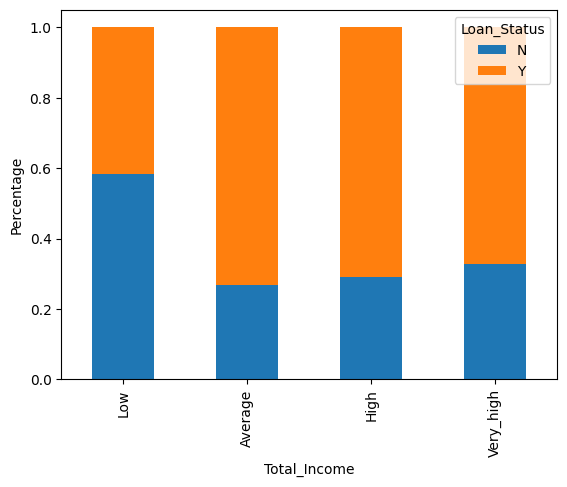

In [26]:
train['Total_Income'] = train['ApplicantIncome'] + train['CoapplicantIncome']
bins = [0,2500,4000,6000,81000]
group = ['Low', 'Average', 'High', 'Very_high']
train['Total_Income_bin']=pd.cut(train['Total_Income'],bins,labels=group)
Total_Income_bin=pd.crosstab(train['Total_Income_bin'],train['Loan_Status'])
Total_Income_bin.div(Total_Income_bin.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)
plt.xlabel('Total_Income')
P = plt.ylabel('Percentage')

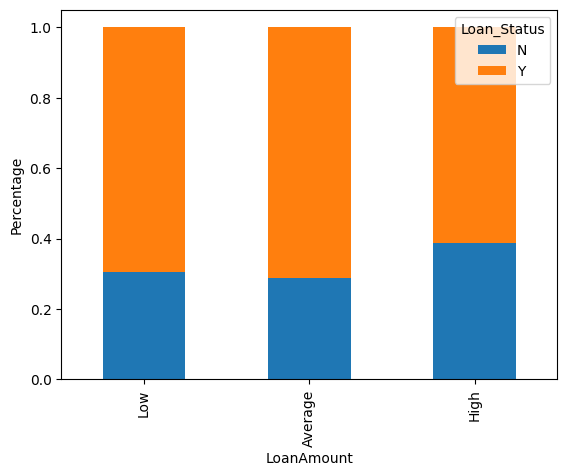

In [27]:
bins=[0,100,200,700]
group=['Low','Average','High']
train['LoanAmount_bin']=pd.cut(train['LoanAmount'],bins,labels=group)
LoanAmount_bin=pd.crosstab(train['LoanAmount_bin'],train['Loan_Status'])
LoanAmount_bin.div(LoanAmount_bin.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)
plt.xlabel('LoanAmount')
P = plt.ylabel('Percentage')

<Axes: xlabel='Property_Area', ylabel='LoanAmount'>

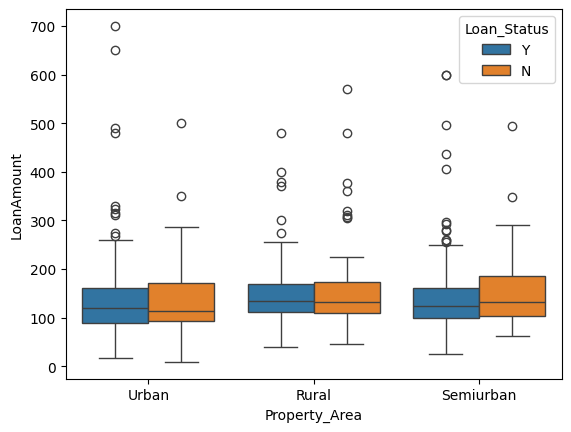

In [28]:
sns.boxplot(x = 'Property_Area', y = 'LoanAmount', hue = 'Loan_Status', data = train)

<Axes: xlabel='Property_Area', ylabel='ApplicantIncome'>

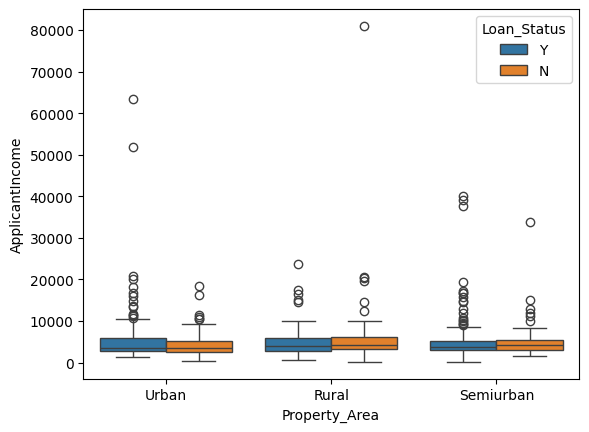

In [29]:
sns.boxplot(x = 'Property_Area', y = 'ApplicantIncome', hue = 'Loan_Status', data = train)

<Axes: xlabel='Credit_History'>

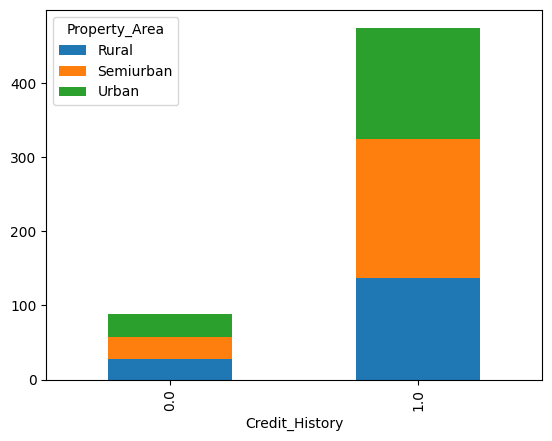

In [30]:
pd.crosstab(train['Credit_History'], train['Property_Area']).plot(kind = 'bar', stacked = True)

In [31]:
train = train.drop(['Income_bin', 'Coapplicant_Income_bin', 'LoanAmount_bin', 'Total_Income' ], axis = 1)

In [32]:
train['Dependents'].replace('3+', 3,inplace=True)
test['Dependents'].replace('3+', 3,inplace=True)
train['Loan_Status'].replace('N', 0,inplace=True)
train['Loan_Status'].replace('Y', 1,inplace=True)

0      1
1      N
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    N
Name: Loan_Status, Length: 614, dtype: object

In [33]:
numerical_df = train.select_dtypes(include = ['int64', 'float64'])

<Axes: >

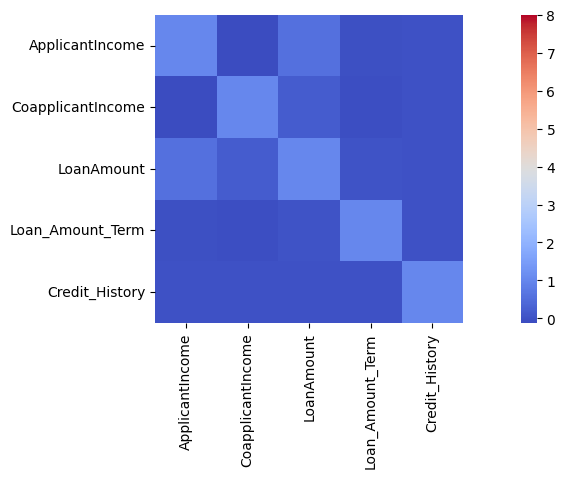

In [34]:
matrix = numerical_df.corr()
f, ax = plt.subplots(figsize = (15,4))
sns.heatmap(matrix, vmax = 8 , square = True, cmap = "coolwarm")

# Missing Values 

In [35]:

train.isnull().sum()  

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
Total_Income_bin      0
dtype: int64

There are missing values in Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term and Credit_History features.
- For numerical variables : imputation using mean or median.  
- For categorical variables : imputation using mode.

In [36]:
test.isna().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [37]:
train['Gender'] = train['Gender'].fillna(train['Gender'].mode()[0], inplace=True)
train['Married'] = train['Married'].fillna(train['Married'].mode()[0], inplace=True)
train['Dependents'] = train['Dependents'].fillna(train['Dependents'].mode()[0], inplace=True)
train['Self_Employed'] = train['Self_Employed'].fillna(train['Self_Employed'].mode()[0], inplace=True)
train['Credit_History'] = train['Credit_History'].fillna(train['Credit_History'].mode()[0], inplace=True)

In [38]:
train['Loan_Amount_Term'] = train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0], inplace = True)

In [39]:
print(train.isnull().sum())

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
Total_Income_bin      0
dtype: int64


In [40]:
train['LoanAmount'] = train['LoanAmount'].fillna(train['LoanAmount'].median(), inplace = True)

In [41]:
train.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Total_Income_bin     0
dtype: int64

In [42]:
test['Gender'] = test['Gender'].fillna(train['Gender'].mode()[0], inplace=True)
test['Dependents'] = test['Dependents'].fillna(train['Dependents'].mode()[0], inplace=True)
test['Self_Employed'] = test['Self_Employed'].fillna(train['Self_Employed'].mode()[0], inplace=True)
test['Credit_History'] = test['Credit_History'].fillna(train['Credit_History'].mode()[0], inplace=True)
test['Loan_Amount_Term'] = test['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0], inplace=True)
test['LoanAmount'] = test['LoanAmount'].fillna(train['LoanAmount'].median(), inplace=True)

In [43]:
test.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

# Outliers Fixing

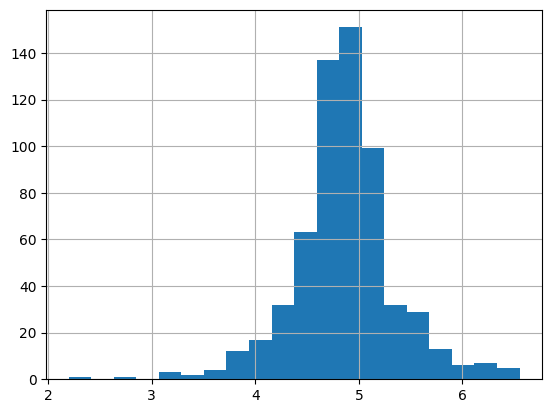

In [44]:
train['LoanAmount_log'] = np.log(train['LoanAmount'])
train['LoanAmount_log'].hist(bins = 20)
test['LoanAmount_log'] = np.log(test['LoanAmount'])

# Data Transformation

In [45]:
train.set_index('Loan_ID', inplace = True)
test.set_index('Loan_ID', inplace = True)

In [46]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income_bin,LoanAmount_log
Loan_ID,,,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,High,4.852030
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,Very_high,4.852030
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,Average,4.189655
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,High,4.787492
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,High,4.948760


In [47]:
train.drop(['Total_Income_bin', 'LoanAmount_log'], axis = 1, inplace = True)


In [48]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [49]:
test.drop([ 'LoanAmount_log'], axis = 1, inplace = True)


In [50]:
test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban
LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


# Categorical Feature Encoding

1.Binary Encoding 

2.One-Hot-Encoding

3.Label Encoding

# Binary Encoding

In [51]:
train['Gender'] = train['Gender'].map({'Male':1, 'Female':0})
train['Married'] = train['Married'].map({'Yes': 1, 'No': 0})
train['Education'] = train['Education'].map({'Graduate': 1, 'Not Graduate': 0})
train['Self_Employed'] = train['Self_Employed'].map({'Yes': 1, 'No': 0})

In [52]:
test['Gender'] = test['Gender'].map({'Male': 1, 'Female': 0})
test['Married'] = test['Married'].map({'Yes': 1, 'No': 0})
test['Education'] = test['Education'].map({'Graduate': 1, 'Not Graduate': 0})
test['Self_Employed'] = test['Self_Employed'].map({'Yes': 1, 'No': 0})

In [53]:
train['Dependents'] = train['Dependents'].replace('3+', 3).astype(int)

In [54]:
test['Dependents'] = test['Dependents'].replace('3+', 3).astype(int)

# One-hot-encoding

In [55]:
train_df_encoded = pd.get_dummies(train, columns = ['Property_Area'], drop_first = True)
train_df_encoded

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Y,False,True
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,N,False,False
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Y,False,True
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Y,False,True
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Y,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
LP002978,0,0,0,1,0,2900,0.0,71.0,360.0,1.0,Y,False,False
LP002979,1,1,3,1,0,4106,0.0,40.0,180.0,1.0,Y,False,False
LP002983,1,1,1,1,0,8072,240.0,253.0,360.0,1.0,Y,False,True


In [56]:
train_df_encoded['Loan_Status'] = train_df_encoded['Loan_Status'].map({'Y': 1,'N': 0})
train_df_encoded = train_df_encoded.astype(int)
train_df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0,128,360,1,1,0,1
LP001003,1,1,1,1,0,4583,1508,128,360,1,0,0,0
LP001005,1,1,0,1,1,3000,0,66,360,1,1,0,1
LP001006,1,1,0,0,0,2583,2358,120,360,1,1,0,1
LP001008,1,0,0,1,0,6000,0,141,360,1,1,0,1


In [57]:
test_df_encoded = pd.get_dummies(test, columns = ['Property_Area'], drop_first = True)

In [58]:
test_df_encoded = test_df_encoded.astype(int)
test_df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110,360,1,0,1
LP001022,1,1,1,1,0,3076,1500,126,360,1,0,1
LP001031,1,1,2,1,0,5000,1800,208,360,1,0,1
LP001035,1,1,2,1,0,2340,2546,100,360,1,0,1
LP001051,1,0,0,0,0,3276,0,78,360,1,0,1


# Label Encoding

In [59]:
from sklearn.preprocessing import LabelEncoder 
le = LabelEncoder()

train['Property_Area'] = le.fit_transform(train['Property_Area'])
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,Y
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,N
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,Y
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,Y
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,Y


In [60]:
test['Property_Area'] = le.fit_transform(test['Property_Area'])
test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,2
LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,2
LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,2
LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,2
LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,2


# Building Model

Splitting data into X and Y (using Label Encoded Data)

In [61]:
x = train.drop('Loan_Status', axis = 1)
y = train['Loan_Status']

In [62]:
x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
LP002978,0,0,0,1,0,2900,0.0,71.0,360.0,1.0,0
LP002979,1,1,3,1,0,4106,0.0,40.0,180.0,1.0,0
LP002983,1,1,1,1,0,8072,240.0,253.0,360.0,1.0,2


In [63]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [64]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(491, 11)
(123, 11)
(491,)
(123,)


# Building KNN MODEL

In [65]:
from sklearn.neighbors import KNeighborsClassifier 
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [66]:
print("KNN train Score: ", knn.score(x_train, y_train))
print("KNN test Score: ", knn.score(x_test, y_test))


KNN train Score:  0.7352342158859471
KNN test Score:  0.5772357723577236


In [67]:
scores = []
for k in range(1,40):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(x_train, y_train)
    scores.append(knn.score(x_test, y_test))
scores

[0.5853658536585366,
 0.5528455284552846,
 0.6178861788617886,
 0.5609756097560976,
 0.5772357723577236,
 0.5691056910569106,
 0.5853658536585366,
 0.5853658536585366,
 0.5772357723577236,
 0.5609756097560976,
 0.6016260162601627,
 0.5853658536585366,
 0.5934959349593496,
 0.5853658536585366,
 0.6097560975609756,
 0.6178861788617886,
 0.6260162601626016,
 0.6341463414634146,
 0.6178861788617886,
 0.6178861788617886,
 0.6504065040650406,
 0.6260162601626016,
 0.6260162601626016,
 0.6260162601626016,
 0.6666666666666666,
 0.6504065040650406,
 0.6504065040650406,
 0.6422764227642277,
 0.6504065040650406,
 0.6504065040650406,
 0.6504065040650406,
 0.6504065040650406,
 0.6504065040650406,
 0.6585365853658537,
 0.6504065040650406,
 0.6585365853658537,
 0.6504065040650406,
 0.6504065040650406,
 0.6504065040650406]

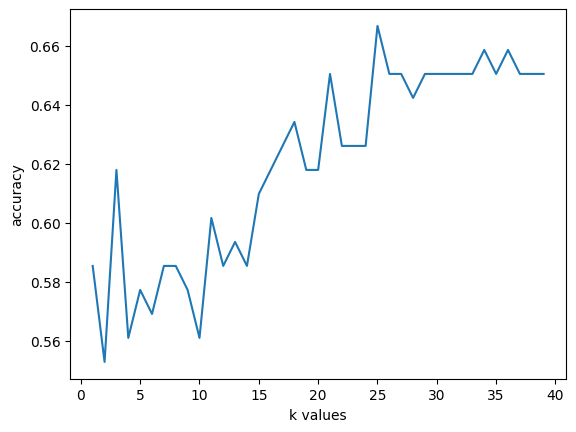

In [68]:
plt.plot(range(1,40), scores)
plt.xlabel('k values')
plt.ylabel('accuracy')
plt.show()

In [69]:
knn = KNeighborsClassifier(n_neighbors = 25)
knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",25
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [70]:
print("KNN train Score: ", knn.score(x_train, y_train))
print("KNN test Score: ", knn.score(x_test, y_test))

KNN train Score:  0.7087576374745418
KNN test Score:  0.6666666666666666


In [71]:
from sklearn.metrics import accuracy_score 
y_pred = knn.predict(x_test)
knn_accuracy = accuracy_score(y_test, y_pred)
knn_accuracy

0.6666666666666666

In [72]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           N       1.00      0.05      0.09        43
           Y       0.66      1.00      0.80        80

    accuracy                           0.67       123
   macro avg       0.83      0.52      0.44       123
weighted avg       0.78      0.67      0.55       123



# Building SVM Model

In [73]:
from sklearn.svm import SVC 
svm = SVC(kernel = 'linear')
svm.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [74]:
print("SVM train Score:", svm.score(x_train, y_train))
print("SVM test Score:", svm.score(x_test, y_test))

SVM train Score: 0.8024439918533605
SVM test Score: 0.7886178861788617


In [75]:
y_pred = svm.predict(x_test)
svm_accuracy = accuracy_score(y_test, y_pred)
print("SVM Accuracy: ", svm_accuracy)

SVM Accuracy:  0.7886178861788617


In [76]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           N       1.00      0.40      0.57        43
           Y       0.75      1.00      0.86        80

    accuracy                           0.79       123
   macro avg       0.88      0.70      0.71       123
weighted avg       0.84      0.79      0.76       123



# Building Decision Tree

In [77]:
from sklearn.tree import DecisionTreeClassifier 
dt = DecisionTreeClassifier(criterion = 'entropy', max_depth = 3)
dt.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [78]:
y_pred = dt.predict(x_test)
dt_accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy: ", dt_accuracy)

Decision Tree Accuracy:  0.7886178861788617


In [79]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           N       0.95      0.42      0.58        43
           Y       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



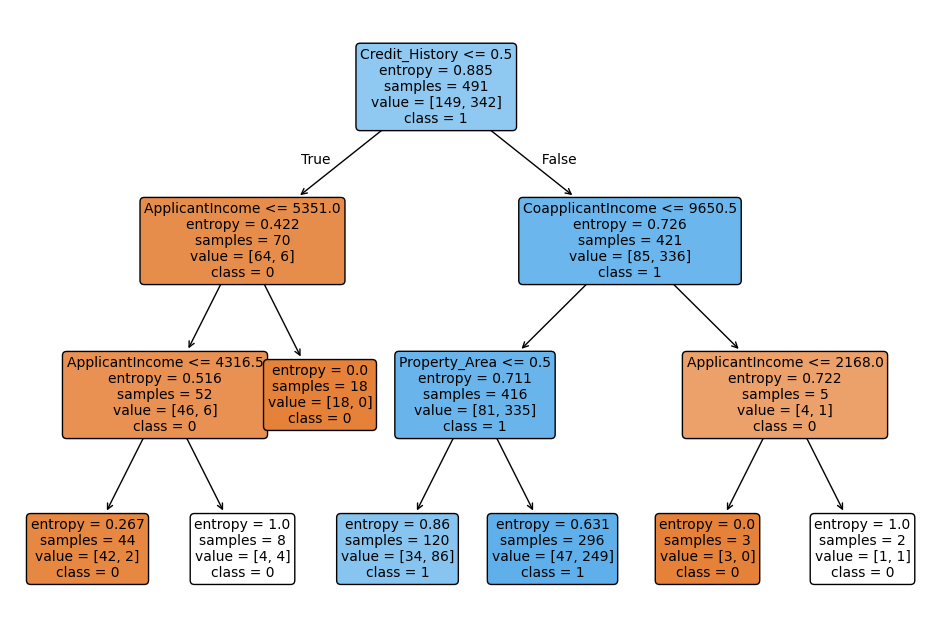

In [80]:
from sklearn.tree import plot_tree
plt.figure(figsize = (12,8))
plot_tree(dt, feature_names = x.columns, class_names = ['0', '1'], filled = True, rounded = True, fontsize = 10)
plt.show()

# Model Performance on Test Data

In [81]:
test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,2
LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,2
LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,2
LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,2
LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,2


In [82]:
test_predictions_knn = knn.predict(test)

In [83]:
output = pd.DataFrame({'Loan_ID':test_original['Loan_ID'], 'Loan_Status':test_predictions_knn})
output.to_csv("test_predictions_knn.csv", index = False)

In [84]:
test_predictions_svm = svm.predict(test)

output = pd.DataFrame({'Loan_ID':test_original['Loan_ID'], 'Loan_Status':test_predictions_svm})
output.to_csv("test_predictions_svm.csv", index = False)

In [85]:
test_predictions_dt = dt.predict(test)

output = pd.DataFrame({'Loan_ID':test_original['Loan_ID'], 'Loan_Status':test_predictions_dt})
output.to_csv("test_predictions_dt.csv", index = False)

# Model Comparison

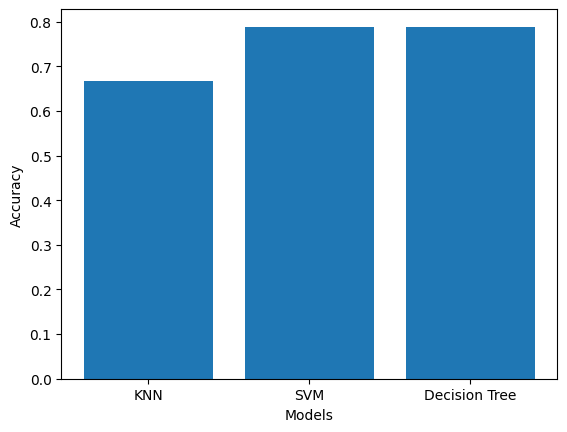

In [86]:
models = ['KNN', 'SVM', 'Decision Tree']
accuracy = [knn_accuracy, svm_accuracy, dt_accuracy]
plt.bar(models, accuracy)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

In [87]:
train['ApplicantIncome_log'] = np.log(train['ApplicantIncome'])
train['LoanAmount_log'] = np.log(train['LoanAmount'])

In [88]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_log,LoanAmount_log
Loan_ID,,,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,Y,8.674026,4.852030
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,N,8.430109,4.852030
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,Y,8.006368,4.189655
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,Y,7.856707,4.787492
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,Y,8.699515,4.948760


<Axes: >

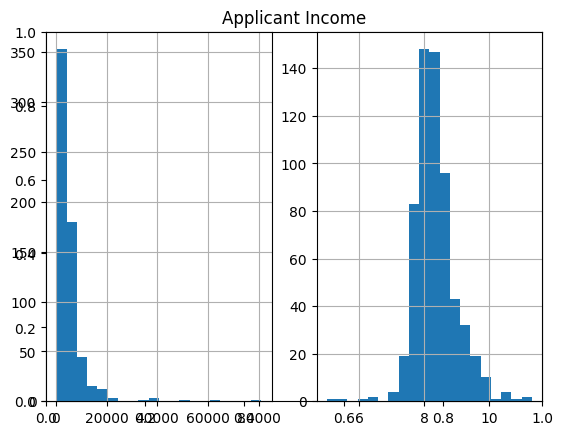

In [89]:
plt.figure(1)
plt.title("Applicant Income")

plt.subplot(121)
train['ApplicantIncome'].hist(bins = 20)

plt.subplot(122)
train['ApplicantIncome_log'].hist(bins = 20)

In [90]:
train['CoapplicantIncome_log_offset'] = np.log(train['CoapplicantIncome'] + 1)

In [91]:
train['CoapplicantIncome_log'] = np.sqrt(train['CoapplicantIncome'])

<Axes: >

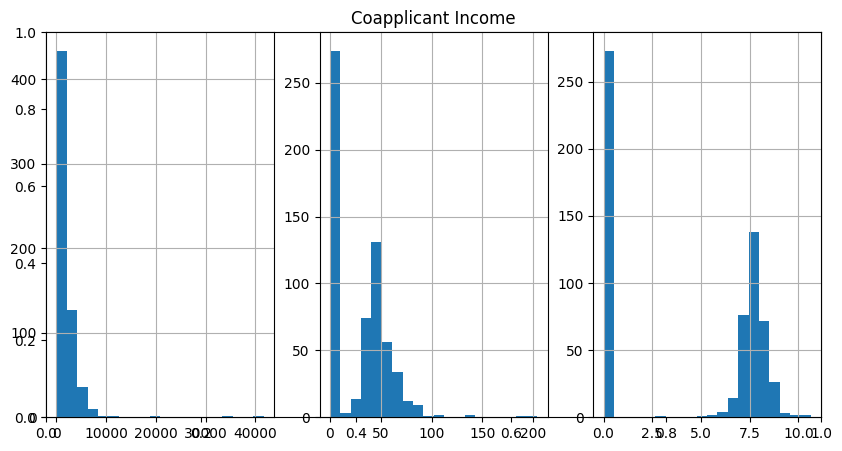

In [92]:
plt.figure(figsize = (10,5))
plt.title('Coapplicant Income')
plt.subplot(131)
train['CoapplicantIncome'].hist(bins = 20)
plt.subplot(132)
train['CoapplicantIncome_log'].hist(bins = 20)
plt.subplot(133)
train['CoapplicantIncome_log_offset'].hist(bins = 20)

In [93]:
train = train.drop(['ApplicantIncome', 'LoanAmount', 'CoapplicantIncome_log_offset', 'CoapplicantIncome'], axis=1)


In [94]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log
Loan_ID,,,,,,,,,,,,
LP001002,1,0,0,1,0,360.0,1.0,2,Y,8.674026,4.852030,0.000000
LP001003,1,1,1,1,0,360.0,1.0,0,N,8.430109,4.852030,38.832976
LP001005,1,1,0,1,1,360.0,1.0,2,Y,8.006368,4.189655,0.000000
LP001006,1,1,0,0,0,360.0,1.0,2,Y,7.856707,4.787492,48.559242
LP001008,1,0,0,1,0,360.0,1.0,2,Y,8.699515,4.948760,0.000000


In [95]:
test['ApplicantIncome_log'] = np.log(test['ApplicantIncome'])
test['LoanAmount_log'] = np.log(test['LoanAmount'])
test['CoapplicantIncome_log'] = np.sqrt(test['CoapplicantIncome'])
test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log
Loan_ID,,,,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,2,8.651724,4.700480,0.000000
LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,2,8.031385,4.836282,38.729833
LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,2,8.517193,5.337538,42.426407
LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,2,7.757906,4.605170,50.457903
LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,2,8.094378,4.356709,0.000000


In [96]:
test.drop(['ApplicantIncome', 'LoanAmount', 'CoapplicantIncome'], axis = 1, inplace = True)

In [97]:
test.columns


Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'ApplicantIncome_log', 'LoanAmount_log', 'CoapplicantIncome_log'],
      dtype='str')

In [98]:
train.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'ApplicantIncome_log', 'LoanAmount_log', 'CoapplicantIncome_log'],
      dtype='str')

# Feature Importance: Base Model

In [99]:
x = train.drop('Loan_Status', axis = 1)
y = train['Loan_Status']


In [100]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [101]:
dt = DecisionTreeClassifier(criterion = 'entropy', max_depth = 3)
dt.fit(x_train, y_train)

y_pred = dt.predict(x_test)
dt_accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy: ", dt_accuracy)

Decision Tree Accuracy:  0.7886178861788617


In [102]:
svm = SVC(kernel = 'linear')
svm.fit(x_train, y_train)
y_pred = svm.predict(x_test)
svm_accuracy = accuracy_score(y_test, y_pred)
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.7886178861788617


# Feature Importance: LOFO on Decision Tree

In [103]:
feature_importance = {}
for feature in x.columns:
    x_train_reduced = x_train.drop(columns = [feature])
    x_test_reduced = x_test.drop(columns = [feature])
    dt.fit(x_train_reduced, y_train)
    y_pred_reduced = dt.predict(x_test_reduced)
    reduced_accuracy = accuracy_score(y_test, y_pred_reduced)
    performance_drop = dt_accuracy - reduced_accuracy 
    feature_importance[feature] = performance_drop 

sorted_importance = sorted(feature_importance.items(), key = lambda x:x[1], reverse = True)
print("\nFeature Importance (LOFO): ")
for feature, drop in sorted_importance:
    print(f"{feature}: Performance Drop = {drop:.4f}")


Feature Importance (LOFO): 
Credit_History: Performance Drop = 0.1545
Gender: Performance Drop = 0.0000
Married: Performance Drop = 0.0000
Dependents: Performance Drop = 0.0000
Education: Performance Drop = 0.0000
Self_Employed: Performance Drop = 0.0000
Loan_Amount_Term: Performance Drop = 0.0000
Property_Area: Performance Drop = 0.0000
ApplicantIncome_log: Performance Drop = 0.0000
LoanAmount_log: Performance Drop = 0.0000
CoapplicantIncome_log: Performance Drop = 0.0000


# Feature Importance : LOFO on SVM

In [104]:
feature_importance = {}
for feature in x.columns:
    x_train_reduced = x_train.drop(columns = [feature])
    x_test_reduced = x_test.drop(columns = [feature])
    svm.fit(x_train_reduced, y_train)
    y_pred_reduced = svm.predict(x_test_reduced)
    reduced_accuracy = accuracy_score(y_test, y_pred_reduced)
    performance_drop = svm_accuracy - reduced_accuracy 
    feature_importance[feature] = performance_drop 

sorted_importance = sorted(feature_importance.items(), key = lambda x:x[1], reverse = True)
print("\nFeature Importance (LOFO): ")
for feature, drop in sorted_importance:
    print(f"{feature}: Performance Drop = {drop:.4f}")


Feature Importance (LOFO): 
Credit_History: Performance Drop = 0.1382
Gender: Performance Drop = 0.0000
Married: Performance Drop = 0.0000
Dependents: Performance Drop = 0.0000
Education: Performance Drop = 0.0000
Self_Employed: Performance Drop = 0.0000
Loan_Amount_Term: Performance Drop = 0.0000
Property_Area: Performance Drop = 0.0000
ApplicantIncome_log: Performance Drop = 0.0000
LoanAmount_log: Performance Drop = 0.0000
CoapplicantIncome_log: Performance Drop = 0.0000


# Final ML Model with Hyperparameter Tuning

In [105]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [106]:
x = train[['Loan_Amount_Term','Credit_History', 'ApplicantIncome_log', 'LoanAmount_log', 'CoapplicantIncome_log']]
y = train['Loan_Status']

In [107]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [108]:
dt_model = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
dt_model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [109]:
param_grid = {
    'max_depth' : [3,5,7,10,15],
    'min_samples_split' : [2,5,10,20],
    'min_samples_leaf' : [1,5,10,20],
    'max_leaf_nodes' : [10,20,50]
}

In [110]:
grid_search = GridSearchCV(estimator = dt_model,
                           param_grid = param_grid,
                           cv = 5, 
                           scoring = 'accuracy' , 
                           n_jobs = -1, 
                           verbose = 2
                          )

In [111]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_leaf_nodes': [10, 20, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [112]:
print("best Hyperparameters from Grid Search: ", grid_search.best_params_)

best Hyperparameters from Grid Search:  {'max_depth': 3, 'max_leaf_nodes': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}


In [113]:
best_dt_model = grid_search.best_estimator_
y_pred = best_dt_model.predict(x_test)


In [114]:
train_preds = best_dt_model.predict(x_train)
test_preds = best_dt_model.predict(x_test)
training_accuracy = accuracy_score(y_train, train_preds)
testing_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy {training_accuracy:.4f}")
print(f"testing Accuracy {testing_accuracy:.4f}")

Training Accuracy 0.8147
testing Accuracy 0.7805


In [115]:
print("Classification Report (Grid search")
print(classification_report(y_test, y_pred))

Classification Report (Grid search
              precision    recall  f1-score   support

           N       0.86      0.44      0.58        43
           Y       0.76      0.96      0.85        80

    accuracy                           0.78       123
   macro avg       0.81      0.70      0.72       123
weighted avg       0.80      0.78      0.76       123



In [116]:
from scipy.stats import randint 
param_dist = {
    'max_depth' : randint(3,15),
    'min_samples_split': randint(2,20),
    'min_samples_leaf': randint(1,20),
    'max_leaf_nodes' : randint(10,100)
}

In [117]:
random_search = RandomizedSearchCV(estimator = dt_model, 
                                   param_distributions = param_dist,
                                   n_iter = 100,
                                   scoring = 'accuracy',
                                   n_jobs = -1, 
                                   verbose = 2
                                  )

In [118]:
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....t 0x126b93230>, 'max_leaf_nodes': <scipy.stats....t 0x12730c9e0>, 'min_samples_leaf': <scipy.stats....t 0x12730cd10>, 'min_samples_split': <scipy.stats....t 0x1242de330>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Gu

In [119]:
print("best Hyperparameters from Random Search: ", random_search.best_params_)

best Hyperparameters from Random Search:  {'max_depth': 7, 'max_leaf_nodes': 12, 'min_samples_leaf': 19, 'min_samples_split': 5}


In [120]:
best_dt_model = random_search.best_estimator_
y_pred = best_dt_model.predict(x_test)


In [121]:
train_preds = best_dt_model.predict(x_train)
test_preds = best_dt_model.predict(x_test)
training_accuracy = accuracy_score(y_train, train_preds)
testing_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy {training_accuracy:.4f}")
print(f"testing Accuracy {testing_accuracy:.4f}")

Training Accuracy 0.8167
testing Accuracy 0.7480


In [122]:
print("Classification Report (Random search")
print(classification_report(y_test, y_pred))

Classification Report (Random search
              precision    recall  f1-score   support

           N       0.71      0.47      0.56        43
           Y       0.76      0.90      0.82        80

    accuracy                           0.75       123
   macro avg       0.74      0.68      0.69       123
weighted avg       0.74      0.75      0.73       123



# Hyperparameter on SVM

In [123]:
svm = SVC()

param_grid = {
    'C' : [0.1,1,10,100], # Regularization parameter
    'kernel' : ['linear', 'rbf', 'poly'], #kernal type
    'gamma' : ['scale', 'auto', 0.1,0.01, 0.001] #kernal coefficient 
}


In [ ]:
grid_search = GridSearchCV(estimator = svm,
                           param_grid = param_grid, 
                           cv = 5, 
                           n_jobs = -1 ,
                           verbose = 1)
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


In [ ]:
print('Best parameters:', grid_search.best_params_)
print("best cross validation score:", grid_search.best_score_)


In [ ]:
svm_model = grid_search.best_estimator_
y_pred = svm_model.predict(x_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
from scipy.stats import randint 
param_dist = {
    'max_depth' : randint(3,15),
    'min_samples_split': randint(2,20),
    'min_samples_leaf': randint(1,20),
    'max_leaf_nodes' : randint(10,100)
}

In [ ]:
random_search_svm = RandomizedSearchCV(estimator = svm_model, 
                                   param_distributions = param_dist,
                                   n_iter = 100,
                                   scoring = 'accuracy',
                                   n_jobs = -1, 
                                   verbose = 2
                                  )

In [ ]:
random_search_svm.fit(x_train, y_train)

In [ ]:
print("best Hyperparameters from Random Search: ", random_search_svm.best_params_)

In [ ]:
best_dt_model = random_search_svm.best_estimator_
y_pred = best_dt_model.predict(x_test)


In [ ]:
train_preds = best_dt_model.predict(x_train)
test_preds = best_dt_model.predict(x_test)
training_accuracy = accuracy_score(y_train, train_preds)
testing_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy {training_accuracy:.4f}")
print(f"testing Accuracy {testing_accuracy:.4f}")

In [ ]:
print("Classification Report (Random search")
print(classification_report(y_test, y_pred))